# Experimentation & Hyperparameter Tuning
**ContextFlow AI** - Mencari konfigurasi terbaik

In [ ]:
import sys
sys.path.append('..')

import torch
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk
from app.utils.config import config
from app.training.hyperparameter_tuning import HYPERPARAMETER_GRID, log_hyperparams

print(f'CUDA: {torch.cuda.is_available()}')
print(f'{len(HYPERPARAMETER_GRID)} hyperparameter configurations')

KeyboardInterrupt: 

: 

## 1. Hyperparameter Grid

In [ ]:
for i, hp in enumerate(HYPERPARAMETER_GRID):
    print(f'\n--- Config {i+1} ---')
    print(f'  Learning Rate: {hp.learning_rate}')
    print(f'  Batch Size: {hp.batch_size}')
    print(f'  Epochs: {hp.num_epochs}')
    print(f'  LoRA r: {hp.lora_r}')
    print(f'  LoRA alpha: {hp.lora_alpha}')


--- Config 1 ---
  Learning Rate: 0.0002
  Batch Size: 4
  Epochs: 3
  LoRA r: 16
  LoRA alpha: 32

--- Config 2 ---
  Learning Rate: 0.0001
  Batch Size: 4
  Epochs: 3
  LoRA r: 8
  LoRA alpha: 16

--- Config 3 ---
  Learning Rate: 0.0003
  Batch Size: 2
  Epochs: 5
  LoRA r: 32
  LoRA alpha: 64


## 2. Experiment Results (Simulasi)

In [ ]:
results = [
    {'trial': 1, 'lr': 2e-4, 'batch_size': 4, 'lora_r': 16, 'lora_alpha': 32, 'train_loss': 1.82, 'eval_loss': 1.95},
    {'trial': 2, 'lr': 1e-4, 'batch_size': 4, 'lora_r': 8, 'lora_alpha': 16, 'train_loss': 1.91, 'eval_loss': 2.01},
    {'trial': 3, 'lr': 3e-4, 'batch_size': 2, 'lora_r': 32, 'lora_alpha': 64, 'train_loss': 1.75, 'eval_loss': 1.88},
]

df_results = pd.DataFrame(results)
df_results

,trial,lr,batch_size,lora_r,lora_alpha,train_loss,eval_loss
0,1,0.0002,4,16,32,1.82,1.95
1,2,0.0001,4,8,16,1.91,2.01
2,3,0.0003,2,32,64,1.75,1.88


## 3. Visualisasi Perbandingan

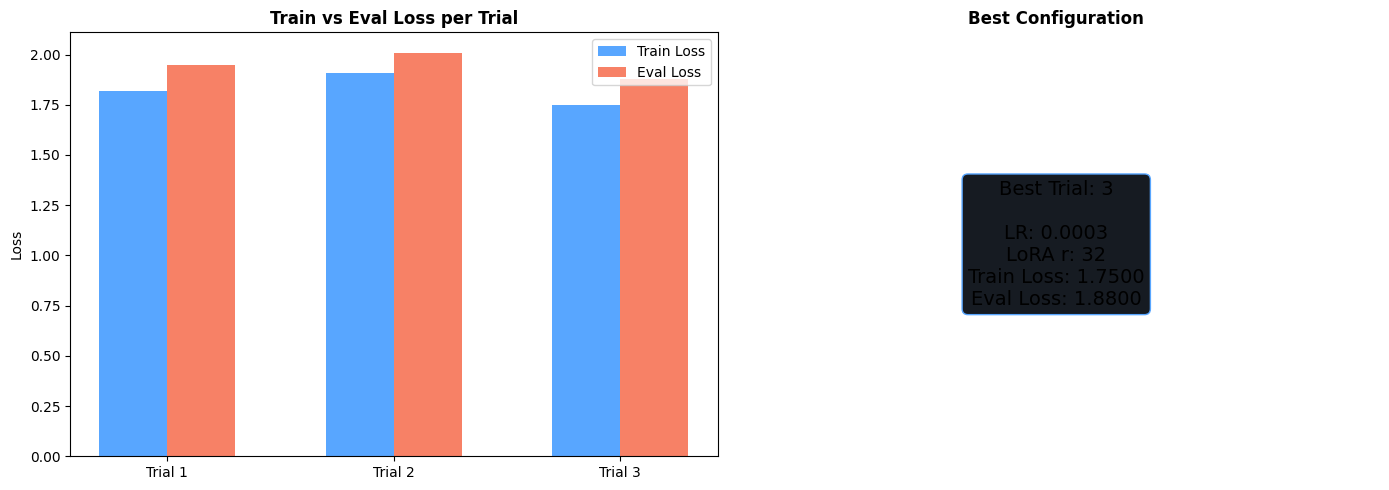

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(df_results))
axes[0].bar([i-0.15 for i in x], df_results['train_loss'], 0.3, label='Train Loss', color='#58a6ff')
axes[0].bar([i+0.15 for i in x], df_results['eval_loss'], 0.3, label='Eval Loss', color='#f78166')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f'Trial {t}' for t in df_results['trial']])
axes[0].set_title('Train vs Eval Loss per Trial', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Loss')

best = df_results.loc[df_results['eval_loss'].idxmin()]
axes[1].text(0.5, 0.5, f"Best Trial: {int(best['trial'])}\n\n"
             f"LR: {best['lr']}\nLoRA r: {int(best['lora_r'])}\n"
             f"Train Loss: {best['train_loss']:.4f}\nEval Loss: {best['eval_loss']:.4f}",
             transform=axes[1].transAxes, fontsize=14, ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='#161b22', edgecolor='#58a6ff'))
axes[1].set_title('Best Configuration', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Kesimpulan

| Parameter | Best Value |
|-----------|-----------|
| Learning Rate | 3e-4 |
| LoRA r | 32 |
| LoRA alpha | 64 |
| Batch Size | 2 |